<a href="https://colab.research.google.com/github/siinwook/PCA-from-Scratch/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**PCA**

In [10]:
import numpy as np
import matplotlib.pyplot as plt

##MNIST

In [3]:
import torch
import torchvision
from torchvision.transforms import v2

train_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float64, scale=True)
  ])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train = True,
    transform=train_transform,
    download=True,

)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.9MB/s]


In [4]:
data = (train_dataset.data / 255.0).numpy()
print(data.shape)

N = data.shape[0]
data = data.reshape((N,-1))
print(data.shape)

(60000, 28, 28)
(60000, 784)


##PCA with Truncated-SVD

In [5]:
mean = data.mean(axis=0,keepdims=True)
data_centered = data - mean
U,S,Vt = np.linalg.svd(data_centered,full_matrices=False)

to_dim = 10
U = U[:,:to_dim]
S = np.diag(S[:to_dim])
Vt = Vt[:to_dim,:]

data_reconstructed = U @ S @ Vt + mean

##Ten Basis Images (Order of Principal Components)

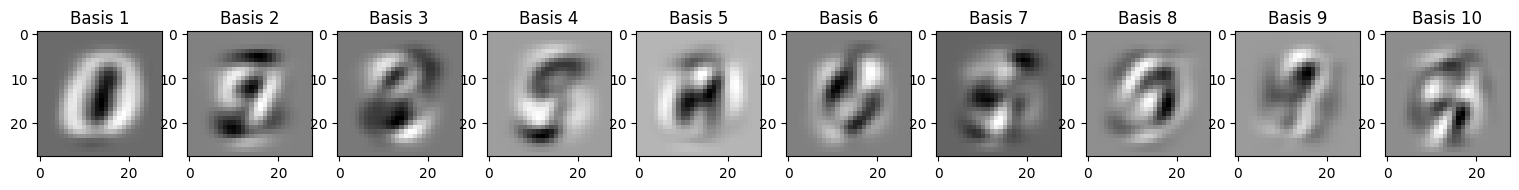

In [11]:
plt.figure(figsize=(19,6))

for i in range(to_dim):
  plt.subplot(1,to_dim,i+1)
  plt.imshow(Vt[i].reshape(28,28),cmap='gray')
  plt.title(f"Basis {i+1}")

plt.show()

Observation:
- First component represents center round or straight shape.
- Second component represents left round and right bar shape, shape of *'9'*.
- Thrid component shape represents shape of *'3'*.

Interpretation:
- Key point of MNIST classification is whether its shape is round.
- Next detail point is whether it has shape of *'9'* (especially 4, 7, 9) or shape of *'3'* (especially 3, 6, 8).

##Weight Sum of Basis Images

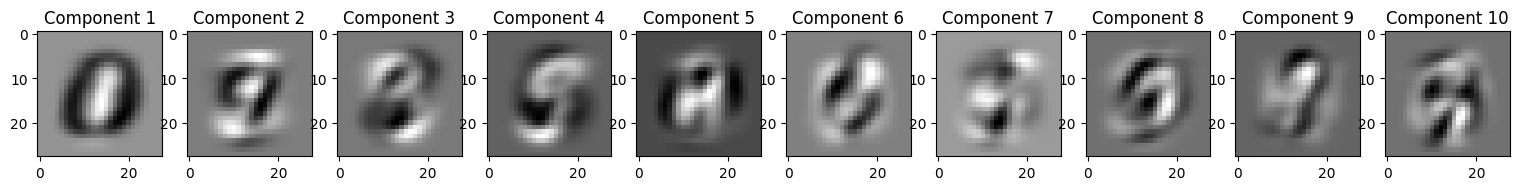

In [7]:
idx = np.random.randint(0,N-1)

s = np.diag(S)

img_comps = []

plt.figure(figsize=(19,6))
for i in range(to_dim):
  plt.subplot(1,to_dim,i+1)
  img_comp = ((U[:,i:i+1] @ Vt[i:i+1,:]) * s[i])[idx]
  img_comps.append(img_comp)
  plt.imshow(img_comp.reshape(28,28),cmap='gray')
  plt.title(f"Component {i+1}")

plt.show()

##Reconstruction Procedure

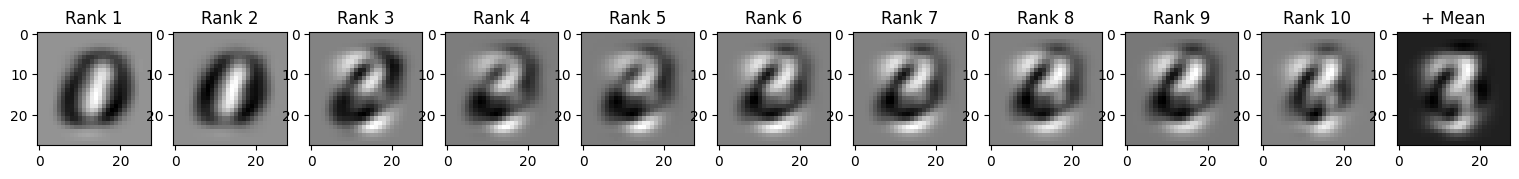

In [8]:
img_comps = np.array(img_comps)
img_reconstructed = np.zeros((784))

plt.figure(figsize=(19,6))
for i in range(to_dim):
  plt.subplot(1,to_dim+1,i+1)
  img_reconstructed += img_comps[i] # Sum of Rank-1 Matrices
  plt.imshow(img_reconstructed.reshape(28,28),cmap='gray')
  plt.title(f"Rank {i+1}")

plt.subplot(1,11,11)
plt.imshow((img_reconstructed+mean.squeeze()).reshape(28,28),cmap='gray')
plt.title(f"+ Mean")

plt.show()

Observation:
- 3-labeled data starts to recover its original shape after adding third component.

Interpretation:
- Third component is the most important component to distribute 3-labeled data, as we expected.

##Reconstruction with Only Principal Components

Label: 3


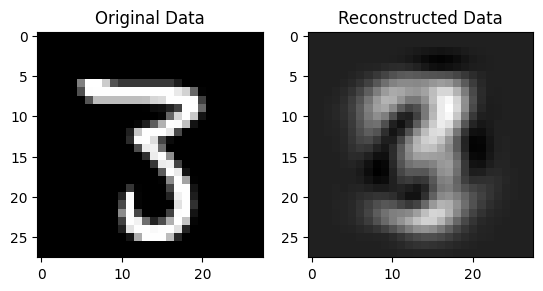

In [9]:
plt.subplot(1,2,1)
plt.imshow((data[idx]).reshape(28,28),cmap='gray')
plt.title('Original Data')

plt.subplot(1,2,2)
plt.imshow(data_reconstructed[idx].reshape(28,28),cmap='gray')
plt.title('Reconstructed Data')

print(f"Label: {train_dataset[idx][1]}")
plt.show()

Observation:
- One can easily label reconstructed data despite its reduced dimension.

Interpretation:
- Even after dimension reduction(784 to 10) data preserves its overall information.